In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

print(f"Pandas version: {pd.__version__}") # Print pandas version to confirm installation

Pandas version: 2.2.3


In [2]:
from decimal import Decimal, ROUND_HALF_UP

In [3]:
# Read the CSV file
# and store into a DataFrame

file = "Verisk_SouthYorkshire_Correct_premise_floor_count.csv"
df = pd.read_csv(file)

In [4]:
# correct error in premise floor count (removed comma) in 3,5; 2,8; 2,3; 1,3 and 1,2

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614589 entries, 0 to 614588
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Unnamed: 0              614589 non-null  int64  
 1   fid                     614589 non-null  int64  
 2   id                      614589 non-null  int64  
 3   premise_age             614589 non-null  object 
 4   premise_age (Simplify)  614589 non-null  object 
 5   premise_use             614589 non-null  object 
 6   premise_type            614585 non-null  object 
 7   premise_floor_count     614529 non-null  float64
 8   height                  614421 non-null  float64
 9   premise_area            614589 non-null  float64
 10  building_area           614589 non-null  float64
 11  gross_area              614529 non-null  float64
dtypes: float64(5), int64(3), object(4)
memory usage: 56.3+ MB


In [6]:
# dropping columns 

df = df.drop([
'Unnamed: 0' 
],axis=1)

In [7]:
# Get to know data
premise_floor_count_list = df['premise_floor_count'].unique()
print("\npremise_floor_count with index numbers:")
for i, N_premise_floor_count in enumerate(premise_floor_count_list):
    count_F = len(df[df['premise_floor_count'] == N_premise_floor_count ])
    print(f"{i}: {N_premise_floor_count} ({count_F} records)")


premise_floor_count with index numbers:
0: 2.0 (426419 records)
1: 3.0 (36641 records)
2: 1.0 (147344 records)
3: 4.0 (3585 records)
4: 5.0 (364 records)
5: 6.0 (67 records)
6: 7.0 (21 records)
7: 11.0 (19 records)
8: 14.0 (5 records)
9: 8.0 (20 records)
10: 9.0 (14 records)
11: 10.0 (2 records)
12: 12.0 (7 records)
13: 13.0 (13 records)
14: 15.0 (5 records)
15: 32.0 (1 records)
16: nan (0 records)
17: 18.0 (2 records)


In [8]:
df.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area
0,87,1831662,1990-1999,1990-1999,Residential,Detached,2.0,9.3,429.6,429.6,859.2
1,655,18725985,Pre 1837,Pre-1919,Residential,Terrace,2.0,8.8,405.3,405.3,810.6


In [9]:
# Get to know data
premise_type_list = df['premise_type'].unique()
print("\npremise_type with index numbers:")
for i, N_premise_type in enumerate(premise_type_list):
    count_PT = len(df[df['premise_type'] == N_premise_type ])
    print(f"{i}: {N_premise_type} ({count_PT} records)")


premise_type with index numbers:
0: Detached (110887 records)
1: Terrace (35439 records)
2: Semi-detached (228880 records)
3: Domestic outbuilding (112796 records)
4: Unknown (7199 records)
5: Mid-terrace (74465 records)
6: End-terrace (35894 records)
7: Flat (7172 records)
8: Maisonette (1635 records)
9: Enclosed end-terrace (161 records)
10: Enclosed mid-terrace (57 records)
11: nan (0 records)


In [10]:
# drop rows with "Domestic outbuilding" 
df = df[df["premise_type"].str.contains("Domestic outbuilding") == False]

In [11]:
# drop rows with "Flat" 
df = df[df["premise_type"].str.contains("Flat") == False]

In [12]:
# drop rows with "Maisonette" 
df = df[df["premise_type"].str.contains("Maisonette") == False]

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 492982 entries, 0 to 614588
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   fid                     492982 non-null  int64  
 1   id                      492982 non-null  int64  
 2   premise_age             492982 non-null  object 
 3   premise_age (Simplify)  492982 non-null  object 
 4   premise_use             492982 non-null  object 
 5   premise_type            492982 non-null  object 
 6   premise_floor_count     492924 non-null  float64
 7   height                  492817 non-null  float64
 8   premise_area            492982 non-null  float64
 9   building_area           492982 non-null  float64
 10  gross_area              492924 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 45.1+ MB


In [14]:
# Get to know data
premise_floor_count_list = df['premise_floor_count'].unique()
print("\npremise_floor_count with index numbers:")
for i, N_premise_floor_count in enumerate(premise_floor_count_list):
    count_F = len(df[df['premise_floor_count'] == N_premise_floor_count ])
    print(f"{i}: {N_premise_floor_count} ({count_F} records)")


premise_floor_count with index numbers:
0: 2.0 (424779 records)
1: 3.0 (31112 records)
2: 1.0 (34548 records)
3: 4.0 (2342 records)
4: 5.0 (123 records)
5: 6.0 (15 records)
6: 9.0 (1 records)
7: 32.0 (1 records)
8: 13.0 (1 records)
9: nan (0 records)
10: 18.0 (2 records)


In [15]:
df['premise_type'] = df['premise_type'].str.replace('Enclosed end-terrace', 'End-terrace')

In [16]:
df['premise_type'] = df['premise_type'].str.replace('Enclosed mid-terrace', 'Mid-terrace')

In [17]:
# Get to know data
premise_type_list = df['premise_type'].unique()
print("\npremise_type with index numbers:")
for i, N_premise_type in enumerate(premise_type_list):
    count_PT = len(df[df['premise_type'] == N_premise_type ])
    print(f"{i}: {N_premise_type} ({count_PT} records)")


premise_type with index numbers:
0: Detached (110887 records)
1: Terrace (35439 records)
2: Semi-detached (228880 records)
3: Unknown (7199 records)
4: Mid-terrace (74522 records)
5: End-terrace (36055 records)


# Bungalow: B-DT and B-SD

In [18]:
# Dataframe for Bungalow Only
# Select floor count is 1
dfb = df[(df.premise_floor_count == 1)]

In [19]:
dfb.info()

<class 'pandas.core.frame.DataFrame'>
Index: 34548 entries, 78 to 614588
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fid                     34548 non-null  int64  
 1   id                      34548 non-null  int64  
 2   premise_age             34548 non-null  object 
 3   premise_age (Simplify)  34548 non-null  object 
 4   premise_use             34548 non-null  object 
 5   premise_type            34548 non-null  object 
 6   premise_floor_count     34548 non-null  float64
 7   height                  34542 non-null  float64
 8   premise_area            34548 non-null  float64
 9   building_area           34548 non-null  float64
 10  gross_area              34548 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 3.2+ MB


In [20]:
dfb['Archetype'] = np.where(dfb['premise_type'] == 'Detached', 'B-DT', 'B-SD')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\1689063452.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfb['Archetype'] = np.where(dfb['premise_type'] == 'Detached', 'B-DT', 'B-SD')


In [21]:
# Get to know data
premise_type_list2 = dfb['premise_type'].unique()
print("\npremise_type with index numbers:")
for i, N_premise_type in enumerate(premise_type_list2):
    count_PT2 = len(dfb[dfb['premise_type'] == N_premise_type ])
    print(f"{i}: {N_premise_type} ({count_PT2} records)")


premise_type with index numbers:
0: Semi-detached (12679 records)
1: Detached (17001 records)
2: Terrace (957 records)
3: Unknown (377 records)
4: Mid-terrace (1665 records)
5: End-terrace (1869 records)


In [22]:
dfb.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
78,735,301315,1945-1959,1945-1959,Residential,Semi-detached,1.0,6.2,106.5,106.5,106.5,B-SD
79,736,85697,1919-1944,1919-1944,Residential,Semi-detached,1.0,6.9,89.4,89.4,89.4,B-SD


In [23]:
# get count per type
bungalow_archetype = dfb['Archetype'].value_counts()
print(bungalow_archetype)

Archetype
B-SD    17547
B-DT    17001
Name: count, dtype: int64


# Dataframe for houses with fewer than 4 storeys

In [24]:
dfh1 = df[df['premise_floor_count'] != 1]

In [25]:
dfh = dfh1[dfh1['premise_floor_count'] < 4]

In [26]:
dfh.info()

<class 'pandas.core.frame.DataFrame'>
Index: 455891 entries, 0 to 614587
Data columns (total 11 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   fid                     455891 non-null  int64  
 1   id                      455891 non-null  int64  
 2   premise_age             455891 non-null  object 
 3   premise_age (Simplify)  455891 non-null  object 
 4   premise_use             455891 non-null  object 
 5   premise_type            455891 non-null  object 
 6   premise_floor_count     455891 non-null  float64
 7   height                  455732 non-null  float64
 8   premise_area            455891 non-null  float64
 9   building_area           455891 non-null  float64
 10  gross_area              455891 non-null  float64
dtypes: float64(5), int64(2), object(4)
memory usage: 41.7+ MB


# Houses - Detached

In [27]:
# Select "Detached" 
dfd = dfh[(dfh.premise_type == "Detached")]

In [28]:
cond_DT = [
    dfd['gross_area'] <= 150, dfd['gross_area'] > 150
]

In [29]:
choice_DT = ['DT-R', 'DT-L or DT-V']

In [30]:
dfd['Archetype'] = np.select(cond_DT, choice_DT, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\2773433288.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfd['Archetype'] = np.select(cond_DT, choice_DT, default='Unknown')


In [31]:
dfd.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
0,87,1831662,1990-1999,1990-1999,Residential,Detached,2.0,9.3,429.6,429.6,859.2,DT-L or DT-V
3,658,18621856,1919-1944,1919-1944,Residential,Detached,2.0,4.1,77.9,77.9,155.8,DT-L or DT-V


In [32]:
dfd.info()

<class 'pandas.core.frame.DataFrame'>
Index: 93423 entries, 0 to 614585
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   fid                     93423 non-null  int64  
 1   id                      93423 non-null  int64  
 2   premise_age             93423 non-null  object 
 3   premise_age (Simplify)  93423 non-null  object 
 4   premise_use             93423 non-null  object 
 5   premise_type            93423 non-null  object 
 6   premise_floor_count     93423 non-null  float64
 7   height                  93423 non-null  float64
 8   premise_area            93423 non-null  float64
 9   building_area           93423 non-null  float64
 10  gross_area              93423 non-null  float64
 11  Archetype               93423 non-null  object 
dtypes: float64(5), int64(2), object(5)
memory usage: 9.3+ MB


In [33]:
# get count per type
detached_archetype = dfd['Archetype'].value_counts()
print(detached_archetype)

Archetype
DT-L or DT-V    65977
DT-R            27446
Name: count, dtype: int64


# Semi-Detached Houses: SD-R, SD-S and SD-V

In [34]:
# Select "Semi-Detached" under Houses
dfs = dfh[(dfh.premise_type == "Semi-detached")]

In [35]:
cond_SD = [
    dfs['gross_area'] <= 100,
    (dfs['gross_area'] > 100) & (dfs['gross_area'] < 150),
    dfs['gross_area'] >= 150
]

In [36]:
choice_SD = ['SD-R', 'SD-S', 'SD-V']

In [37]:
dfs['Archetype'] = np.select(cond_SD, choice_SD, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\189937462.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfs['Archetype'] = np.select(cond_SD, choice_SD, default='Unknown')


In [38]:
dfs.tail(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
614554,652410,665026,1919-1944,1919-1944,Residential,Semi-detached,2.0,9.5,106.5,106.5,213.0,SD-V
614557,652413,38902,1870-1918,Pre-1919,Residential,Semi-detached,2.0,8.7,71.2,71.2,142.4,SD-S


In [39]:
# get count per type
semi_archetype = dfs['Archetype'].value_counts()
print(semi_archetype)

Archetype
SD-S    109739
SD-R     61095
SD-V     45367
Name: count, dtype: int64


# End-Terrace Houses: TR-E, TV-E and TG-E

In [40]:
# Select "End-Terrace" under Houses
dfe = dfh[(dfh.premise_type == "End-terrace")]

In [41]:
cond_TE = [
    dfe['gross_area'] <= 110,
    (dfe['gross_area'] > 110) & (dfe['gross_area'] < 200),
    dfe['gross_area'] >= 200
]

In [42]:
choice_TE = ['TR-E', 'TV-E', 'TG-E']

In [43]:
dfe['Archetype'] = np.select(cond_TE, choice_TE, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\759632165.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfe['Archetype'] = np.select(cond_TE, choice_TE, default='Unknown')


In [44]:
dfe.head(3)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
1119,2372,18768813,1870-1918,Pre-1919,Residential,End-terrace,2.0,5.9,91.2,91.2,182.4,TV-E
1557,3242,18628437,1980-1989,1980-1989,Residential,End-terrace,2.0,7.2,76.9,288.5,153.8,TV-E
1559,3244,18769170,1960-1979,1960-1979,Residential,End-terrace,2.0,7.7,67.0,177.6,134.0,TV-E


In [45]:
# get count per type
endterrace_archetype = dfe['Archetype'].value_counts()
print(endterrace_archetype)

Archetype
TR-E    16687
TV-E    15609
TG-E     1425
Name: count, dtype: int64


# Mid-Terrace Houses: TR-M, TV-M and TG-M

In [46]:
# Select "Mid-Terrace" under Houses
dfm = dfh[(dfh.premise_type == "Mid-terrace")]

In [47]:
cond_TM = [
    dfm['gross_area'] <= 110,
    (dfm['gross_area'] > 110) & (dfm['gross_area'] < 200),
    dfm['gross_area'] >= 200
]

In [48]:
choice_TM = ['TR-M', 'TV-M', 'TG-M']

In [49]:
dfm['Archetype'] = np.select(cond_TM, choice_TM, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\2654450631.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfm['Archetype'] = np.select(cond_TM, choice_TM, default='Unknown')


In [50]:
dfm.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
1107,2358,18598733,1960-1979,1960-1979,Residential,Mid-terrace,2.0,6.7,52.9,390.9,105.8,TR-M
1561,3246,18769178,1960-1979,1960-1979,Residential,Mid-terrace,2.0,7.2,47.5,177.6,95.0,TR-M


In [51]:
# get count per type
midterrace_archetype = dfm['Archetype'].value_counts()
print(midterrace_archetype)

Archetype
TR-M    45102
TV-M    25417
TG-M     1460
Name: count, dtype: int64


# Terrace Houses: TR, TV and TG

In [52]:
# Select "Mid-Terrace" under Houses
dft = dfh[(dfh.premise_type == "Terrace")]

In [53]:
cond_TT = [
    dft['gross_area'] <= 110,
    (dft['gross_area'] > 110) & (dft['gross_area'] < 200),
    dft['gross_area'] >= 200
]

In [54]:
choice_TT = ['TR', 'TV', 'TG']

In [55]:
dft['Archetype'] = np.select(cond_TT, choice_TT, default='Unknown')

C:\Users\May Zune\AppData\Local\Temp\ipykernel_24536\3825490222.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dft['Archetype'] = np.select(cond_TT, choice_TT, default='Unknown')


In [56]:
dft.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
1,655,18725985,Pre 1837,Pre-1919,Residential,Terrace,2.0,8.8,405.3,405.3,810.6,TG
81,739,102899,Pre 1919,Pre-1919,Residential,Terrace,2.0,8.1,177.4,177.4,354.8,TG


In [57]:
# get count per type
terrace_archetype = dft['Archetype'].value_counts()
print(terrace_archetype)

Archetype
TR    16058
TV    10918
TG     6868
Name: count, dtype: int64


# All Archetype Codes

In [58]:
# concat both DataFrames into a single DataFrame

dfarchetype = pd.concat([bungalow_archetype, detached_archetype, semi_archetype, midterrace_archetype, endterrace_archetype, terrace_archetype])

In [59]:
dfarchetype.head(20)

Archetype
B-SD             17547
B-DT             17001
DT-L or DT-V     65977
DT-R             27446
SD-S            109739
SD-R             61095
SD-V             45367
TR-M             45102
TV-M             25417
TG-M              1460
TR-E             16687
TV-E             15609
TG-E              1425
TR               16058
TV               10918
TG                6868
Name: count, dtype: int64

In [60]:
archetype = pd.DataFrame(dfarchetype)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15],
 [Text(0, 0, 'B-SD'),
  Text(1, 0, 'B-DT'),
  Text(2, 0, 'DT-L or DT-V'),
  Text(3, 0, 'DT-R'),
  Text(4, 0, 'SD-S'),
  Text(5, 0, 'SD-R'),
  Text(6, 0, 'SD-V'),
  Text(7, 0, 'TR-M'),
  Text(8, 0, 'TV-M'),
  Text(9, 0, 'TG-M'),
  Text(10, 0, 'TR-E'),
  Text(11, 0, 'TV-E'),
  Text(12, 0, 'TG-E'),
  Text(13, 0, 'TR'),
  Text(14, 0, 'TV'),
  Text(15, 0, 'TG')])

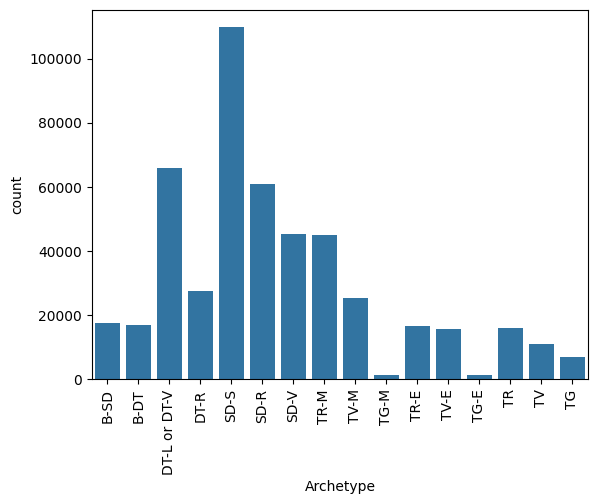

In [61]:
sns.barplot(dfarchetype)
plt.xticks(rotation=90)

# Check DT-L, DT-V, DT-R

In [62]:
dfd.tail(3)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
614580,653695,1752201,1919-1944,1919-1944,Residential,Detached,2.0,8.0,292.7,292.7,585.4,DT-L or DT-V
614583,653699,1752204,1919-1944,1919-1944,Residential,Detached,2.0,8.5,65.6,65.6,131.2,DT-R
614585,653703,2127694,Pre 1919,Pre-1919,Residential,Detached,2.0,8.4,56.3,56.3,112.6,DT-R


In [63]:
# Get to know data
premise_floor_count_list = dfd['premise_floor_count'].unique()
print("\npremise_floor_count with index numbers:")
for i, N_premise_floor_count in enumerate(premise_floor_count_list):
    count_FSC = len(dfd[dfd['premise_floor_count'] == N_premise_floor_count ])
    print(f"{i}: {N_premise_floor_count} ({count_FSC} records)")


premise_floor_count with index numbers:
0: 2.0 (88342 records)
1: 3.0 (5081 records)


# Archetypes

In [64]:
# concat both DataFrames into a single DataFrame

dfverisk = pd.concat([dfb, dfd, dfs, dfe, dfm, dft])

In [65]:
dfverisk.info()

<class 'pandas.core.frame.DataFrame'>
Index: 483716 entries, 78 to 614551
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   fid                     483716 non-null  int64  
 1   id                      483716 non-null  int64  
 2   premise_age             483716 non-null  object 
 3   premise_age (Simplify)  483716 non-null  object 
 4   premise_use             483716 non-null  object 
 5   premise_type            483716 non-null  object 
 6   premise_floor_count     483716 non-null  float64
 7   height                  483551 non-null  float64
 8   premise_area            483716 non-null  float64
 9   building_area           483716 non-null  float64
 10  gross_area              483716 non-null  float64
 11  Archetype               483716 non-null  object 
dtypes: float64(5), int64(2), object(5)
memory usage: 48.0+ MB


In [66]:
dfverisk.head(2)

,fid,id,premise_age,premise_age (Simplify),premise_use,premise_type,premise_floor_count,height,premise_area,building_area,gross_area,Archetype
78,735,301315,1945-1959,1945-1959,Residential,Semi-detached,1.0,6.2,106.5,106.5,106.5,B-SD
79,736,85697,1919-1944,1919-1944,Residential,Semi-detached,1.0,6.9,89.4,89.4,89.4,B-SD


In [67]:
# Get to know data
archetype_type_list = dfverisk['Archetype'].unique()
print("\narchetype_type with index numbers:")
for i, N_archetype in enumerate(archetype_type_list):
    count_AR = len(dfverisk[dfverisk['Archetype'] == N_archetype ])
    print(f"{i}: {N_archetype} ({count_AR} records)")


archetype_type with index numbers:
0: B-SD (17547 records)
1: B-DT (17001 records)
2: DT-L or DT-V (65977 records)
3: DT-R (27446 records)
4: SD-V (45367 records)
5: SD-S (109739 records)
6: SD-R (61095 records)
7: TV-E (15609 records)
8: TG-E (1425 records)
9: TR-E (16687 records)
10: TR-M (45102 records)
11: TV-M (25417 records)
12: TG-M (1460 records)
13: TG (6868 records)
14: TV (10918 records)
15: TR (16058 records)


# Postprocessed data 

In [68]:
# import Excel

Result = pd.read_excel('SY_Archetypes_Quantification_Results.xlsx', sheet_name='stocksize')

In [69]:
df_result= pd.DataFrame(Result)

In [70]:
df_result.head(2)

,Archetype,Verisk,EPC
0,*DT-V,35529,8339.500000
1,DT-L,30448,3697.666667


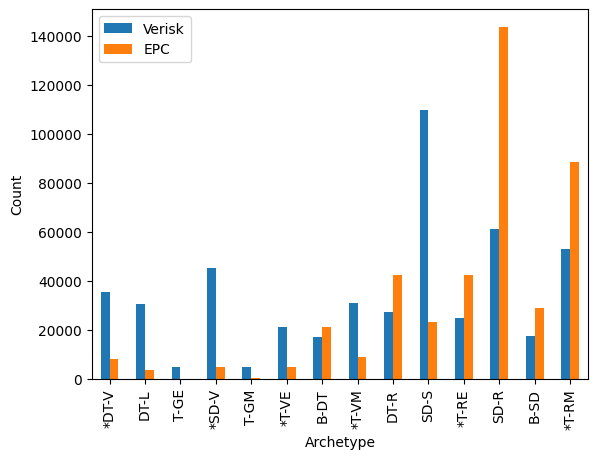

In [71]:
# Plotting side-by-side
df_result.plot(x='Archetype', y=['Verisk', 'EPC'], kind='bar')
plt.ylabel("Count")
plt.show()